In [384]:
import pandas as pd

df = pd.read_csv("Position_Salaries.csv")
pd.options.display.float_format = '{:,.2f}'.format

df.describe()

,Level,Salary,Log_Salary,Normalized_Salary
count,48.00,48.00,48.00,48.00
mean,12.25,"14,254,895.83",14.39,0.49
std,7.00,"26,277,703.45",2.51,0.30
min,0.50,"30,000.00",10.31,0.00
25%,6.38,"168,750.00",12.03,0.21
50%,12.25,"2,400,000.00",14.69,0.53
75%,18.12,"14,500,000.00",16.49,0.74
max,24.00,"120,000,000.00",18.60,1.00


In [385]:
X = df.loc[:, ["Level"]]
y = df["Log_Salary"]

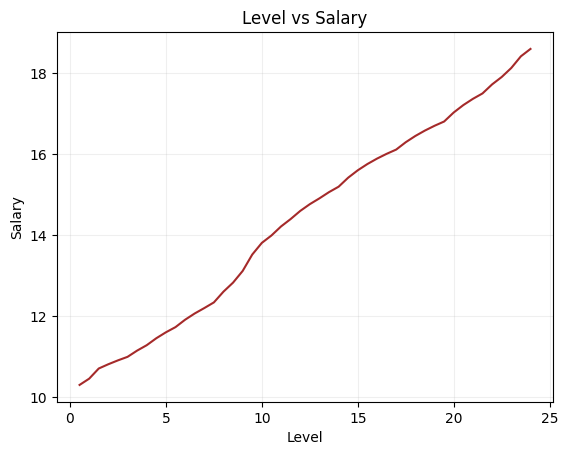

In [386]:
import matplotlib.pyplot as plt

plt.plot(X, y, color="brown")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.show()

In [396]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_transformed = X
X_transformed = pd.DataFrame(X_transformed, columns=["Level"])
X_transformed.head()

,Level
0,0.50
1,1.00
2,1.50
3,2.00
4,2.50


### 1. max_depth

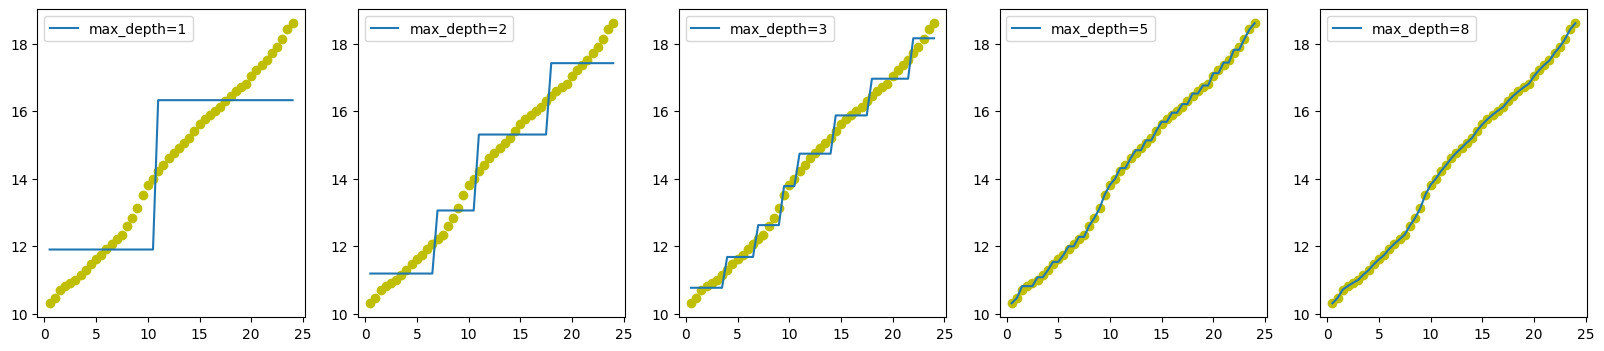

In [397]:
from sklearn.tree import DecisionTreeRegressor

depths = [1, 2, 3, 5, 8]

plt.figure(figsize=(20, 4))

for i, d in enumerate(depths):
    model = DecisionTreeRegressor(max_depth=d)
    model.fit(X_transformed, y)
    y_pred = model.predict(X_transformed)

    plt.subplot(1, len(depths), i+1)
    plt.scatter(X_transformed, y, color="y")
    plt.plot(X_transformed, y_pred, label=f"max_depth={d}")
    plt.legend()

plt.show()

### 2. min_samples_split

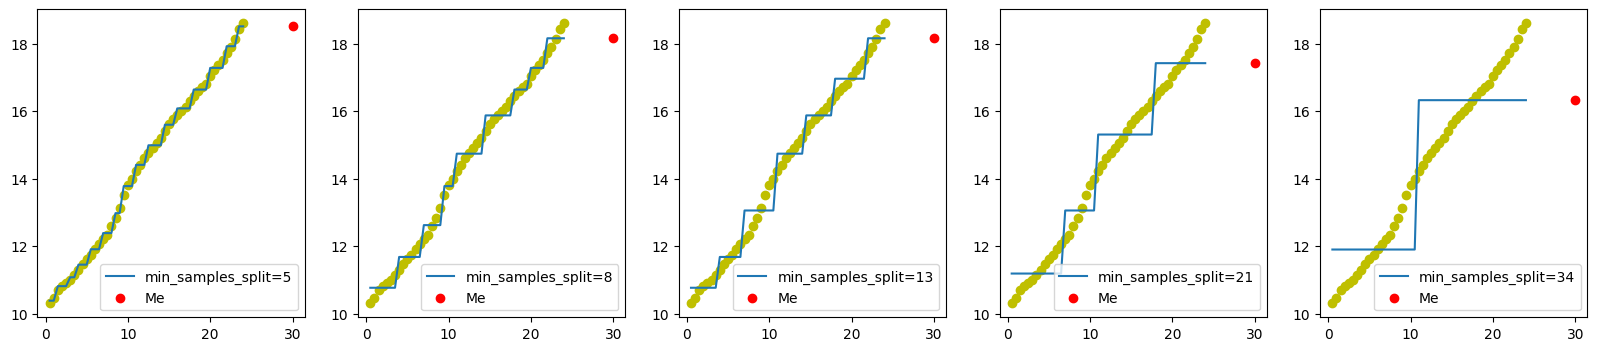

In [417]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split 

splits = [5, 8, 13, 21, 34]

plt.figure(figsize=(20, 4))

for i, s in enumerate(splits):
    model = DecisionTreeRegressor(min_samples_split=s)
    model.fit(X_transformed, y)
    y_pred = model.predict(X_transformed)

    point = pd.DataFrame([{ "Level": 30 }])

    plt.subplot(1, len(depths), i+1)
    plt.scatter(X_transformed, y, color="y")
    plt.plot(X_transformed, y_pred, label=f"min_samples_split={s}")
    plt.scatter(point, model.predict(point), label="Me", color="red")
    plt.legend()

plt.show()

### 3. min_samples_leaf

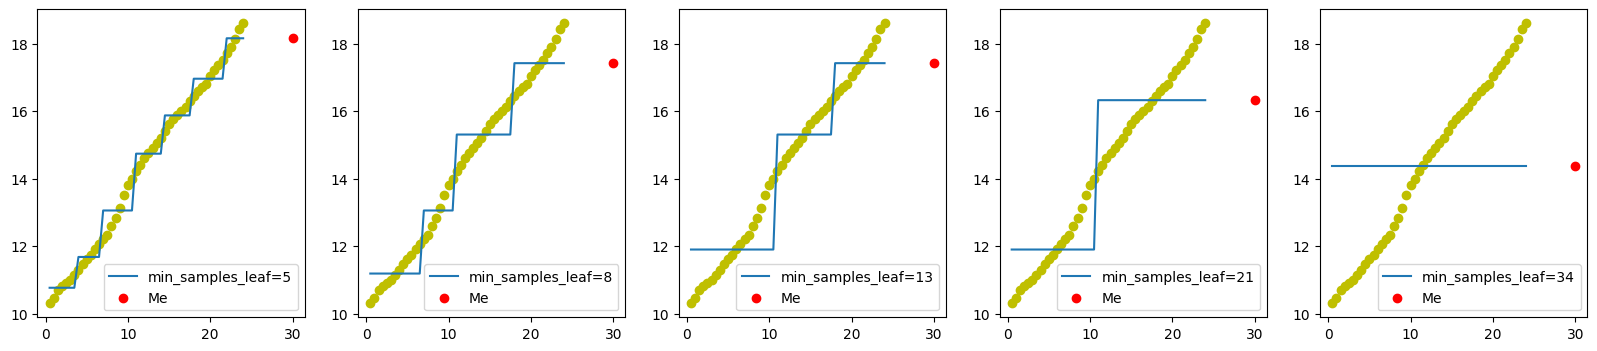

In [415]:
from sklearn.tree import DecisionTreeRegressor

leaves = [5, 8, 13, 21, 34]

plt.figure(figsize=(20, 4))

for i, l in enumerate(leaves):
    model = DecisionTreeRegressor(min_samples_leaf=l)
    model.fit(X_transformed, y)

    point = pd.DataFrame([{ "Level": 30 }])
    
    plt.subplot(1, len(depths), i+1)
    plt.scatter(X_transformed, y, color="y")
    plt.plot(X, model.predict(X), label=f"min_samples_leaf={l}")
    plt.scatter(point, model.predict(point), label="Me", color="red")
    plt.legend()

plt.show()

### 4. max_features

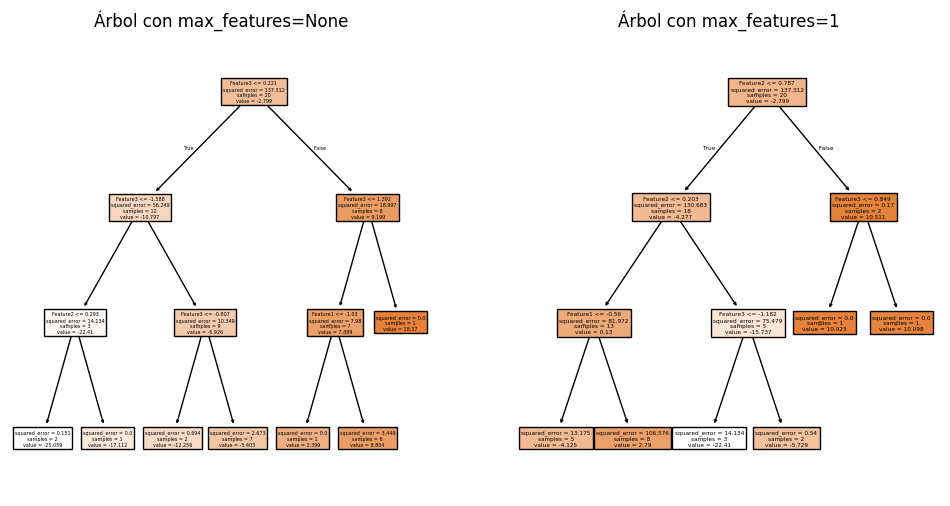

In [378]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Generar un dataset de regresión con 3 características
X, y = make_regression(n_samples=25, n_features=3, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear dos modelos con diferentes max_features
tree_full = DecisionTreeRegressor(max_features=None, random_state=42, max_depth=3)  # Usa todas las características
tree_limited = DecisionTreeRegressor(max_features=1, random_state=42, max_depth=3)  # Solo 1 característica por división

# Entrenar los modelos
tree_full.fit(X_train, y_train)
tree_limited.fit(X_train, y_train)

# Visualizar los árboles
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_tree(tree_full, filled=True, feature_names=["Feature1", "Feature2", "Feature3"])
plt.title("Árbol con max_features=None")

plt.subplot(1, 2, 2)
plot_tree(tree_limited, filled=True, feature_names=["Feature1", "Feature2", "Feature3"])
plt.title("Árbol con max_features=1")

plt.show()